### **1.Consumo di alcol per paese** 
Esegui un’**analisi esplorativa** focalizzata sul **consumo di alcol**.  
Analizza i seguenti aspetti:
* Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)

* Calcola la media del consumo di birra, vino, e distillati

* Crea una nuova colonna alcohol_index che sia: `(beer_servings + wine_servings + spirit_servings) / 3`

* Trova il paese con il valore massimo di alcohol_index

* Filtra solo i paesi che consumano più di 100 birre all’anno

Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

Crea un line plot con wine_servings ordinato per paese (usa sort_values)

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")
df

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,Afghanistan,0,0,0,0.0
1,Albania,89,132,54,4.9
2,Algeria,25,0,14,0.7
3,Andorra,245,138,312,12.4
4,Angola,217,57,45,5.9
...,...,...,...,...,...
188,Venezuela,333,100,3,7.7
189,Vietnam,111,2,1,2.0
190,Yemen,6,0,0,0.1
191,Zambia,32,19,4,2.5


In [34]:
#1.
df.nlargest(10,'total_litres_of_pure_alcohol')

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
15,Belarus,142,373,42,14.4
98,Lithuania,343,244,56,12.9
3,Andorra,245,138,312,12.4
68,Grenada,199,438,28,11.9
45,Czech Republic,361,170,134,11.8
61,France,127,151,370,11.8
141,Russian Federation,247,326,73,11.5
81,Ireland,313,118,165,11.4
99,Luxembourg,236,133,271,11.4
155,Slovakia,196,293,116,11.4


In [37]:
#2.
df[['beer_servings','spirit_servings','wine_servings']].mean()

beer_servings      106.160622
spirit_servings     80.994819
wine_servings       49.450777
dtype: float64

In [38]:
#3.
df['alcohol_index'] = round(df[['beer_servings','spirit_servings','wine_servings']].mean(axis=1),2)

In [ ]:
#4.
df.loc[df.alcohol_index.idxmax(),['country']]

country    Andorra
Name: 3, dtype: str


In [42]:
#5.
df.loc[df.beer_servings > 100 ,['country','beer_servings']]

,country,beer_servings
3,Andorra,245
4,Angola,217
5,Antigua & Barbuda,102
6,Argentina,193
8,Australia,261
...,...,...
182,United Kingdom,219
184,USA,249
185,Uruguay,115
188,Venezuela,333


<BarContainer object of 10 artists>

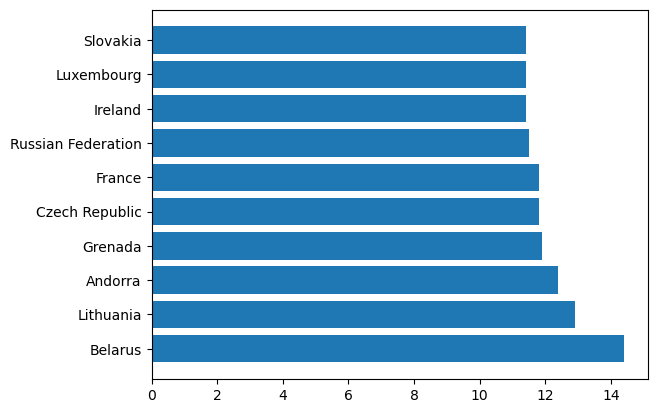

In [43]:
#6.
top10_alc = df.nlargest(10,'total_litres_of_pure_alcohol')
plt.barh(top10_alc['country'], top10_alc['total_litres_of_pure_alcohol'])

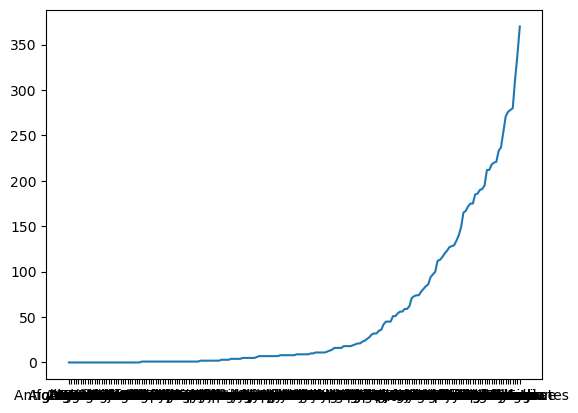

In [49]:
#7.
plt.plot(df.country,df.sort_values(by='wine_servings')['wine_servings'])
plt.show()

### **2.Analisi offerte di lavoro** 

Esegui un’**analisi esplorativa** focalizzata sui **lavori nel campo dei dati in ciascun paese**.  
Analizza i seguenti aspetti per ogni paese:

* Lo **stipendio medio annuale** (`salary_year_avg`)
* Il **numero totale di offerte di lavoro** (job count)
* L’intervallo degli stipendi: **valore minimo e massimo** (`min` / `max`)

Rappresenta graficamente lo stipendio medio (`salary_year_avg`) per `job_title_short` usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.

In [3]:
import pandas as pd
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

df.groupby('job_country')['salary_year_avg'].agg(job_count = 'size',salary_year_avg = 'mean', min ='min', max='max')


c:\Users\Hazem\miniconda3\envs\labProg\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,job_count,salary_year_avg,min,max
job_country,,,,
Afghanistan,16,NaN,NaN,NaN
Albania,119,79472.500000,43200.0,157500.0
Algeria,111,44550.000000,44100.0,45000.0
Angola,11,NaN,NaN,NaN
Argentina,8736,105212.343750,45000.0,222000.0
...,...,...,...,...
Venezuela,69,NaN,NaN,NaN
Vietnam,2414,90927.236364,28000.0,200000.0
Yemen,10,NaN,NaN,NaN


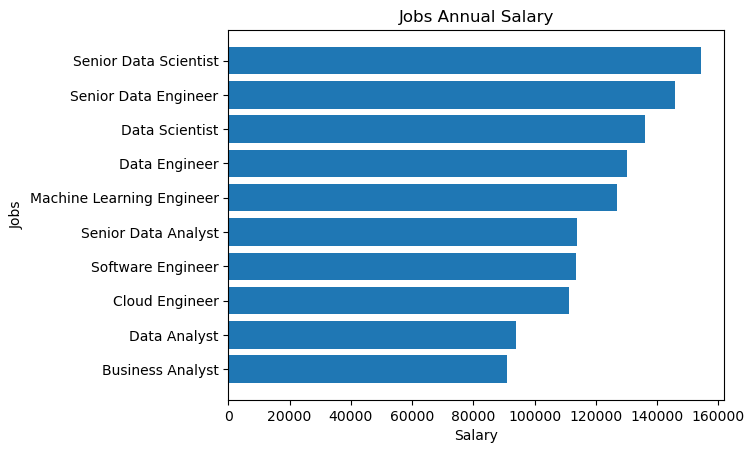

In [34]:
job_sal = df.groupby('job_title_short',)['salary_year_avg'].agg(salary_year_avg = 'mean')
job_sal.sort_values(by='salary_year_avg', inplace=True)
plt.barh(job_sal.index,job_sal.salary_year_avg)
plt.title('Jobs Annual Salary')
plt.xlabel('Salary')
plt.ylabel('Jobs')
plt.show()


### **3. Analisi vendite (dataset tips)**

Esegui un’**analisi esplorativa** focalizzata sulle **vendite giornaliere**.  
Analizza i seguenti aspetti per ogni giorno (`day`):

* Il **conto medio** (`total_bill`)
* Il **numero totale di osservazioni** (conteggio delle righe)
* Il **valore minimo e massimo** del conto (`total_bill` → `min` / `max`)

* Crea una nuova colonna `conto_per_persona` che sia:  
  `total_bill / size`

* Trova il giorno con il **conto medio più alto**

Rappresenta graficamente il **conto medio (`total_bill`) per giorno** usando un **grafico a barre**.  
Ordina i dati dal valore più alto al più basso.  
Aggiungi titolo ed etichette agli assi.

In [ ]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

# 
# df.groupby(by='day')['total_bill'].apply(lambda x: df[df.total_bill == x].iat[0,-1])
# type(df[df.total_bill == 16.99]['conto_per_persona'])



In [20]:
conto_medio_per_giorno = df.groupby(by='day')['total_bill'].mean()
conto_medio_per_giorno

day
Fri     17.151579
Sat     20.441379
Sun     21.410000
Thur    17.682742
Name: total_bill, dtype: float64

In [9]:
df.day.value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

In [6]:
df.groupby(by='day')['total_bill'].agg(['max','min'])

,max,min
day,,
Fri,40.17,5.75
Sat,50.81,3.07
Sun,48.17,7.25
Thur,43.11,7.51


In [ ]:
df['conto_per_persona'] = round(df.total_bill/df['size'],2)

,total_bill,tip,sex,smoker,day,time,size,conto_per_persona
0,16.99,1.01,Female,No,Sun,Dinner,2,8.49
1,10.34,1.66,Male,No,Sun,Dinner,3,3.45
2,21.01,3.50,Male,No,Sun,Dinner,3,7.00
3,23.68,3.31,Male,No,Sun,Dinner,2,11.84
4,24.59,3.61,Female,No,Sun,Dinner,4,6.15
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,9.68
240,27.18,2.00,Female,Yes,Sat,Dinner,2,13.59
241,22.67,2.00,Male,Yes,Sat,Dinner,2,11.34
242,17.82,1.75,Male,No,Sat,Dinner,2,8.91


In [22]:
conto_medio_per_giorno.idxmax()

'Sun'

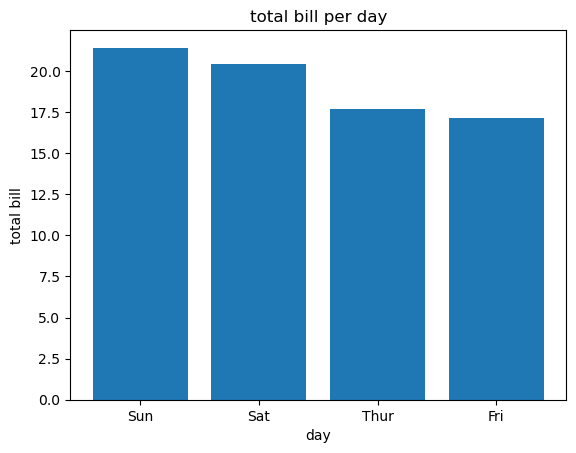

In [31]:
conto_medio_per_giorno.sort_values(ascending=False, inplace=True)
plt.bar(conto_medio_per_giorno.index, conto_medio_per_giorno.values)
plt.xlabel('day')
plt.ylabel('total bill')
plt.title('total bill per day')
plt.show()